# 3 · La búsqueda genética

Los cuadernos 1 y 2 miden. Este decide.

Un plan es una secuencia de paradas —cuándo, y a qué compuesto— y la búsqueda
encuentra el que tiene la mejor **distribución** de resultados sobre cientos de
carreras sorteadas, no el que queda mejor contra una carrera imaginada.

Todo lo que se sortea sale del cuaderno 2.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from boxbox_ml import strategy
from boxbox_ml.strategy import Car, Objective, Plan, RaceModel, Stop, optimise

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.figsize": (9, 3.4), "figure.dpi": 110, "font.size": 9})

MODELO = RaceModel()
print(f"vueltas totales:            {MODELO.total_laps}")
print(f"ruido de una vuelta:        {MODELO.lap_noise_s} s")
print(f"pérdida en verde:           {MODELO.pit_loss_green} (p25, mediana, p75)")
print(f"pérdida bajo safety car:    {MODELO.pit_loss_sc}")
print(f"P(safety car):              {MODELO.p_safety_car}")
print(f"duración del safety car:    {MODELO.sc_laps} vueltas")
print(f"tanda más larga admitida:   {strategy.MAX_STINT}")

vueltas totales:            72
ruido de una vuelta:        0.457 s
pérdida en verde:           (20.2, 22.6, 25.5) (p25, mediana, p75)
pérdida bajo safety car:    (7.5, 19.5, 31.5)
P(safety car):              0.6
duración del safety car:    5 vueltas
tanda más larga admitida:   {'HARD': 41, 'MEDIUM': 31, 'SOFT': 25}


## 3.1 La parrilla

La foto de 2026 R12 Zandvoort en la vuelta 30, la misma que corre el simulador
web.

In [2]:
GRILLA = [
    Car("ANT", "HARD", 9, 0.38, 0.093, 0.0, 30),
    Car("NOR", "HARD", 9, 0.25, 0.064, 0.69, 30),
    Car("RUS", "HARD", 13, 0.36, 0.024, 7.79, 30),
    Car("PIA", "HARD", 12, 0.63, 0.005, 9.65, 30),
    Car("LEC", "MEDIUM", 9, 0.96, 0.161, 10.08, 30),
    Car("HAM", "HARD", 5, 0.53, 0.037, 15.35, 30),
    Car("LAW", "MEDIUM", 9, 0.51, 0.112, 31.85, 30),
    Car("ALO", "SOFT", 28, 0.0, 0.005, 47.94, 30),
    Car("HUL", "SOFT", 11, -1.57, -0.549, 55.3, 30),
    Car("TSU", "HARD", 12, -0.1, -0.399, 59.26, 30),
    Car("LIN", "MEDIUM", 25, 1.77, -0.008, 62.28, 30),
    Car("GAS", "HARD", 12, 1.29, -0.113, 62.58, 30),
    Car("BOR", "MEDIUM", 19, 1.21, 0.205, 63.29, 30),
    Car("ALB", "HARD", 4, 0.0, 0.376, 64.05, 30),
    Car("SAI", "SOFT", 28, 0.0, 0.279, 66.06, 30),
    Car("OCO", "HARD", 14, -1.88, 0.049, 67.55, 30),
    Car("STR", "HARD", 15, 0.13, -0.133, 71.81, 30),
    Car("COL", "HARD", 9, 0.54, 0.378, 81.71, 30),
    Car("PER", "HARD", 1, 0.0, 0.0, 98.35, 30),
    Car("BOT", "HARD", 4, 0.45, 0.0, 99.46, 30),
]
pd.DataFrame([vars(c) for c in GRILLA]).head(8)

,code,compound,tyre_age,degradation_s,degradation_rate,gap_leader_s,from_lap
0,ANT,HARD,9,0.38,0.093,0.00,30
1,NOR,HARD,9,0.25,0.064,0.69,30
2,RUS,HARD,13,0.36,0.024,7.79,30
3,PIA,HARD,12,0.63,0.005,9.65,30
4,LEC,MEDIUM,9,0.96,0.161,10.08,30
5,HAM,HARD,5,0.53,0.037,15.35,30
6,LAW,MEDIUM,9,0.51,0.112,31.85,30
7,ALO,SOFT,28,0.00,0.005,47.94,30


In [3]:
rng = np.random.default_rng(7)


def plan_sorteado(car: Car) -> Plan:
    """El plan de un rival: sorteado de la distribución medida, no optimizado.

    Darle el óptimo a todos describiría una carrera que nadie corrió nunca.
    """
    cuantas = int(rng.choice([0, 1, 2, 3], p=[0.151, 0.493, 0.192, 0.164]))
    paradas, previa = [], car.from_lap
    for _ in range(cuantas):
        share = float(np.interp(rng.random(), [0.05, 0.5, 0.95], [0.458, 0.722, 0.817]))
        lap = max(int(share * MODELO.total_laps), previa + strategy.MIN_STINT)
        if lap > MODELO.total_laps - strategy.MIN_STINT:
            break
        paradas.append(Stop(lap, str(rng.choice(strategy.DRY))))
        previa = lap
    return Plan(tuple(paradas))


PLANES = {c.code: plan_sorteado(c) for c in GRILLA}


def rivales(code: str) -> tuple[list[Car], list[Plan]]:
    resto = [c for c in GRILLA if c.code != code]
    return resto, [PLANES[c.code] for c in resto]


BUSQUEDA = dict(population=24, generations=12, draws=200, seed=7)
print("parámetros de la búsqueda:", BUSQUEDA)

parámetros de la búsqueda: {'population': 24, 'generations': 12, 'draws': 200, 'seed': 7}


## 3.2 El safety car está en la aptitud, no de adorno

Cada carrera sorteada tiene un safety car o ninguno, en una vuelta sorteada de
la distribución medida. Es **el mismo para todos los autos de esa carrera**:
uno que ayuda a alguno perjudica a otro, y sortearlo por auto borraría eso.

carreras con safety car: 0.606  (modelo: 0.6)


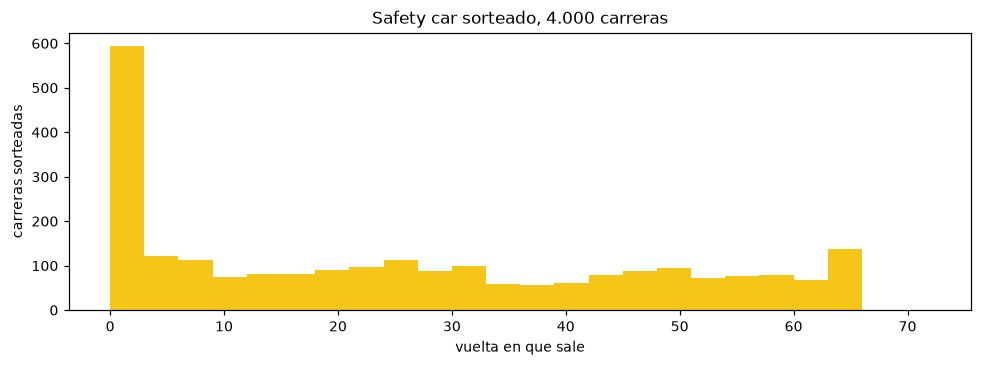

In [4]:
sorteos = strategy.draw_safety_car(MODELO, np.random.default_rng(1), 4000)
print(f"carreras con safety car: {(sorteos >= 0).mean():.3f}  (modelo: {MODELO.p_safety_car})")
fig, ax = plt.subplots()
ax.hist(sorteos[sorteos >= 0], bins=np.arange(0, 73, 3), color="#f5c518")
ax.set_xlabel("vuelta en que sale")
ax.set_ylabel("carreras sorteadas")
ax.set_title("Safety car sorteado, 4.000 carreras")
plt.tight_layout()
plt.show()

In [5]:
# Cuánto cambia el plan recomendado si el safety car no existiera.
sin_sc = RaceModel(p_safety_car=0.0)
lec = next(c for c in GRILLA if c.code == "LEC")
resto, planes = rivales("LEC")
for etiqueta, modelo in (("con safety car al 60%", MODELO), ("sin safety car", sin_sc)):
    hallado = optimise(lec, resto, planes, modelo, objective=Objective.POINTS, **BUSQUEDA)
    print(
        f"{etiqueta:22s} {hallado.best.describe(lec, modelo.total_laps):<14}"
        f" puntos {hallado.mean_points:5.2f}   paradas "
        + " ".join(f"{k}:{v:.2f}" for k, v in hallado.stop_distribution.items())
    )
print("\nLa probabilidad de safety car entra en el precio de cada parada, así que")
print("cambiarla mueve el plan. Es el punto que pedía el enunciado del TP.")

con safety car al 60%  M7-H35         puntos 18.50   paradas 1:0.71 2:0.17 3:0.12
sin safety car         M6-H36         puntos 18.61   paradas 1:0.58 2:0.42

La probabilidad de safety car entra en el precio de cada parada, así que
cambiarla mueve el plan. Es el punto que pedía el enunciado del TP.


## 3.3 ¿Qué es ganar?

La aptitud son los **puntos absolutos** en la bandera, promediados sobre las
carreras sorteadas — no posiciones ganadas. Mantener un puesto de puntos gana
por construcción: quedarse quinto paga 10 en cada sorteo, y un plan que la
mitad de las veces da tercero y la otra mitad octavo (0,5·15 + 0,5·4 = 9,5) no
lo alcanza.

La tabla es no lineal, así que lo que vale un puesto depende de dónde estés.

In [6]:
puntos = np.array(strategy.POINTS)
print("costo de perder un puesto:")
for i in range(9):
    print(f"  P{i + 1} -> P{i + 2}: {puntos[i] - puntos[i + 1]:2d} puntos")
print(f"  P10 -> P11: {puntos[9]:2d} punto, que es todo el puntaje")

costo de perder un puesto:
  P1 -> P2:  7 puntos
  P2 -> P3:  3 puntos
  P3 -> P4:  3 puntos
  P4 -> P5:  2 puntos
  P5 -> P6:  2 puntos
  P6 -> P7:  2 puntos
  P7 -> P8:  2 puntos
  P8 -> P9:  2 puntos
  P9 -> P10:  1 puntos
  P10 -> P11:  1 punto, que es todo el puntaje


El mismo auto bajo cuatro objetivos distintos. Los planes salen diferentes, y
eso es lo que hay que ver.

In [7]:
filas = []
for code in ("ANT", "LEC", "COL"):
    car = next(c for c in GRILLA if c.code == code)
    resto, planes = rivales(code)
    puesto = GRILLA.index(car) + 1
    for objetivo in (Objective.POINTS, Objective.POSITION, Objective.IN_POINTS, Objective.TIME):
        h = optimise(car, resto, planes, MODELO, objective=objetivo, **BUSQUEDA)
        filas.append(
            {
                "auto": f"{code} (P{puesto})",
                "objetivo": objetivo.value,
                "plan": h.best.describe(car, MODELO.total_laps),
                "llega": round(h.mean_position, 2),
                "puntos": round(h.mean_points, 2),
                "convergencia": " ".join(f"{k}:{v:.2f}" for k, v in h.stop_distribution.items()),
            }
        )
pd.DataFrame(filas)

,auto,objetivo,plan,llega,puntos,convergencia
0,ANT (P1),points,H15-H27,1.62,21.26,1:0.83 2:0.17
1,ANT (P1),position,H19-H23,1.58,21.43,1:0.83 2:0.17
2,ANT (P1),in_points,H19-S23,1.78,20.59,1:0.12 2:0.38 3:0.33 4:0.17
3,ANT (P1),time,H19-H23,1.59,21.49,1:0.79 2:0.21
4,LEC (P5),points,M7-H35,2.29,18.50,1:0.71 2:0.17 3:0.12
5,LEC (P5),position,M6-H36,2.33,18.41,1:0.62 2:0.29 3:0.08
6,LEC (P5),in_points,M11-S25-S6,3.46,13.75,1:0.25 2:0.50 3:0.17 4:0.08
7,LEC (P5),time,M6-H36,2.27,18.55,1:0.83 2:0.17
8,COL (P18),points,H32-S10,16.55,0.00,1:0.29 2:0.29 3:0.38 4:0.04
9,COL (P18),position,H6-H36,15.76,0.00,1:0.79 2:0.21


Mirá la fila de **COL con objetivo `points`**: la población final queda
repartida entre una y cuatro paradas en proporciones parecidas. Eso no es una
recomendación prudente, es ruido — todos sus planes suman cero, el objetivo
está **plano** y la búsqueda no tiene nada que escalar. Con objetivo `position`
converge.

Por eso el objetivo por defecto es `ADAPTIVE`: puntos donde los puntos son
alcanzables, posición donde no.

## 3.4 Dos cosas de la foto en las que no se puede confiar

Las dos se descubrieron porque la búsqueda daba disparates, y las dos son
propiedades de los datos, no errores del código.

### El ritmo de caída propio de cada auto casi no predice

Cada auto llega con `degradation_rate`, una pendiente ajustada sobre sus
últimas cinco vueltas. Se compara esa estimación en la vuelta 10 contra lo que
la tanda efectivamente hizo de la 11 en adelante.

In [8]:
from boxbox_ml import cache, features, track_status  # noqa: E402

crudo = pd.read_parquet(cache.cache_dir().parent / "laps_overtaking.parquet")
listo = features.add_degradation(
    features.add_fuel_correction(features.mark_representative(track_status.add_flags(crudo)))
)
limpio = listo[listo["is_representative"] & ~listo["is_neutralised"] & ~listo["red"]]

pares = []
for _, tanda in limpio.groupby(features.STINT_KEYS, dropna=False):
    tanda = tanda.sort_values("stint_lap")
    if len(tanda) < 18:
        continue
    rodante = tanda[tanda["stint_lap"] == 10]["degradation_rate_s_per_lap"]
    resto_t = tanda[tanda["stint_lap"] > 10]
    if rodante.empty or rodante.isna().all() or len(resto_t) < 6:
        continue
    real = np.polyfit(resto_t["stint_lap"], resto_t["lap_time_fuel_corrected"], 1)[0]
    pares.append({"rodante": float(rodante.iloc[0]), "real": float(real)})

comparacion = pd.DataFrame(pares).dropna()
r = comparacion["rodante"].corr(comparacion["real"])
print(f"tandas comparadas: {len(comparacion):,}")
print(f"correlación:                    {r:.3f}")
print(f"desvío de la estimación rodante: {comparacion['rodante'].std():.3f}")
print(f"desvío de lo que pasó de verdad: {comparacion['real'].std():.3f}")
atenuacion = r * comparacion["real"].std() / comparacion["rodante"].std()
print(f"\nencogimiento óptimo: {atenuacion:.3f}   (el código usa {strategy.RATE_SHRINK})")

tandas comparadas: 2,492
correlación:                    0.183
desvío de la estimación rodante: 0.466
desvío de lo que pasó de verdad: 0.127

encogimiento óptimo: 0.050   (el código usa 0.05)


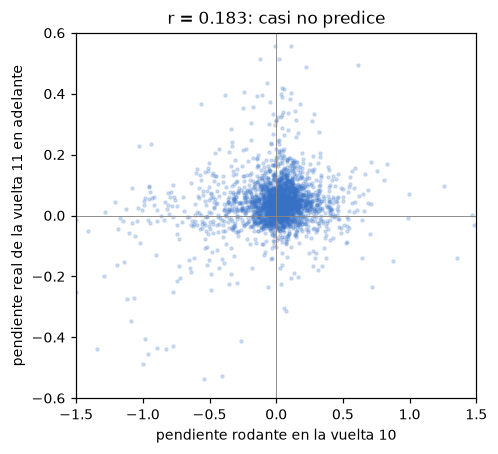

In [9]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(comparacion["rodante"], comparacion["real"], s=4, alpha=0.2, color="#3671c6")
ax.axhline(0, color="#8b8683", lw=0.6)
ax.axvline(0, color="#8b8683", lw=0.6)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.6, 0.6)
ax.set_xlabel("pendiente rodante en la vuelta 10")
ax.set_ylabel("pendiente real de la vuelta 11 en adelante")
ax.set_title(f"r = {r:.3f}: casi no predice")
plt.tight_layout()
plt.show()

Proyectarla cruda no era un error chico. HUL en la foto arrastra
**−0,549 s/vuelta**; extrapolado a treinta vueltas dice que va a ganar cuatro
minutos, y la búsqueda recomendaba un plan que lo hacía **ganar desde noveno**.

In [10]:
hul = next(c for c in GRILLA if c.code == "HUL")
print(f"HUL: degradation_rate = {hul.degradation_rate} s/vuelta")
print(f"extrapolado a 30 vueltas, sin encoger: {hul.degradation_rate * 30 * 29 / 2:.0f} s de ganancia")
print(f"con el encogimiento medido ({strategy.RATE_SHRINK}): "
      f"{hul.degradation_rate * strategy.RATE_SHRINK * 30 * 29 / 2:.0f} s")

HUL: degradation_rate = -0.549 s/vuelta
extrapolado a 30 vueltas, sin encoger: -239 s de ganancia
con el encogimiento medido (0.05): -12 s


### Los autos no andan todos igual

Acumular sólo el cambio de estado de goma asume que sí. LIN, 11.º y a 62 s con
un medio de 25 vueltas, quedaba proyectado **cuarto**, nada más que porque era
el que más tenía para ganar con gomas nuevas.

In [11]:
lin = next(c for c in GRILLA if c.code == "LIN")
base_lin = lin.gap_leader_s / (lin.from_lap - 1) - lin.degradation_s
ant = GRILLA[0]
base_ant = ant.gap_leader_s / (ant.from_lap - 1) - ant.degradation_s
print(f"LIN: {lin.gap_leader_s} s en {lin.from_lap - 1} vueltas = "
      f"{lin.gap_leader_s / (lin.from_lap - 1):.2f} s/vuelta de pérdida media")
print(f"     déficit de goma actual {lin.degradation_s} -> ritmo base {base_lin:+.2f} s/vuelta")
print(f"ANT: ritmo base {base_ant:+.2f} s/vuelta")
print(f"\nLIN pierde {base_lin - base_ant:.2f} s/vuelta más que ANT por auto, no por goma.")
print("Sin ese término, cambiar gomas le devolvía 64 s y lo metía en la pelea.")

LIN: 62.28 s en 29 vueltas = 2.15 s/vuelta de pérdida media
     déficit de goma actual 1.77 -> ritmo base +0.38 s/vuelta
ANT: ritmo base -0.38 s/vuelta

LIN pierde 0.76 s/vuelta más que ANT por auto, no por goma.
Sin ese término, cambiar gomas le devolvía 64 s y lo metía en la pelea.


## 3.5 No parar tampoco estaba en la boleta

La primera versión no podía considerar un plan de cero paradas: la semilla
sorteaba al menos una y cualquier hijo que quedaba vacío se descartaba. Se
había excluido por construcción la opción más conservadora que existe.

Habilitarla dio vuelta medio grid a correr 42 vueltas con un solo juego, y eso
llevó al hallazgo de supervivencia del cuaderno 2. El límite de tanda es la
respuesta: la búsqueda no puede proponer una tanda más larga que el percentil
90 de lo que se corrió de verdad.

In [12]:
sin_limite = RaceModel()
print(f"límite vigente: {strategy.MAX_STINT}")
alb = next(c for c in GRILLA if c.code == "ALB")
print(f"\nALB va en {alb.compound} con {alb.tyre_age} vueltas encima.")
print(f"presupuesto que le queda: {strategy.MAX_STINT[alb.compound] - alb.tyre_age} vueltas")
print(f"vueltas por correr: {MODELO.total_laps - alb.from_lap}")
print("Le falta presupuesto, así que el reparador le fuerza una parada aunque el")
print("sorteo hubiera dicho ninguna. Es el límite de la evidencia hablando, no")
print("una afirmación sobre el neumático.")

límite vigente: {'HARD': 41, 'MEDIUM': 31, 'SOFT': 25}

ALB va en HARD con 4 vueltas encima.
presupuesto que le queda: 37 vueltas
vueltas por correr: 42
Le falta presupuesto, así que el reparador le fuerza una parada aunque el
sorteo hubiera dicho ninguna. Es el límite de la evidencia hablando, no
una afirmación sobre el neumático.


## 3.6 ¿Se comporta como dice la tabla de puntos?

La predicción: la búsqueda debería ser más cautelosa adelante, donde un puesto
cuesta siete puntos, y más jugada donde ya no hay nada que perder.

In [13]:
filas = []
for indice, car in enumerate(GRILLA, start=1):
    resto, planes = rivales(car.code)
    h = optimise(car, resto, planes, MODELO, objective=Objective.ADAPTIVE, **BUSQUEDA)
    filas.append(
        {
            "P": indice,
            "auto": car.code,
            "plan": h.best.describe(car, MODELO.total_laps),
            "llega": round(h.mean_position, 2),
            "±": round(h.sd_position, 2),
            "puntos": round(h.mean_points, 2),
            "vale elegir": round(h.decision_value, 2),
            "objetivo": h.objective.value,
            "paradas": " ".join(f"{k}:{v:.2f}" for k, v in h.stop_distribution.items()),
        }
    )
resultado = pd.DataFrame(filas)
resultado

,P,auto,plan,llega,±,puntos,vale elegir,objetivo,paradas
0,1,ANT,H15-H27,1.62,0.76,21.26,5.48,points,1:0.83 2:0.17
1,2,NOR,H17-H25,1.84,0.94,20.29,7.26,points,1:0.87 2:0.12
2,3,RUS,H6-H36,3.75,1.33,13.45,4.04,points,1:0.62 2:0.38
3,4,PIA,H13-H29,2.72,1.05,16.47,4.27,points,1:0.96 2:0.04
4,5,LEC,M7-H35,2.29,1.19,18.50,7.40,points,1:0.71 2:0.17 3:0.12
5,6,HAM,H6-H36,4.49,1.14,11.32,2.49,points,1:0.75 2:0.25
6,7,LAW,M15-H27,6.81,0.55,6.38,1.24,points,1:0.92 2:0.08
7,8,ALO,S6-H36,9.77,1.55,1.73,2.00,points,1:0.75 2:0.21 3:0.04
8,9,HUL,S14-H28,16.48,0.88,0.00,1.09,position,1:0.83 2:0.17
9,10,TSU,H29-S13,11.47,1.07,0.19,0.29,points,1:0.87 2:0.12


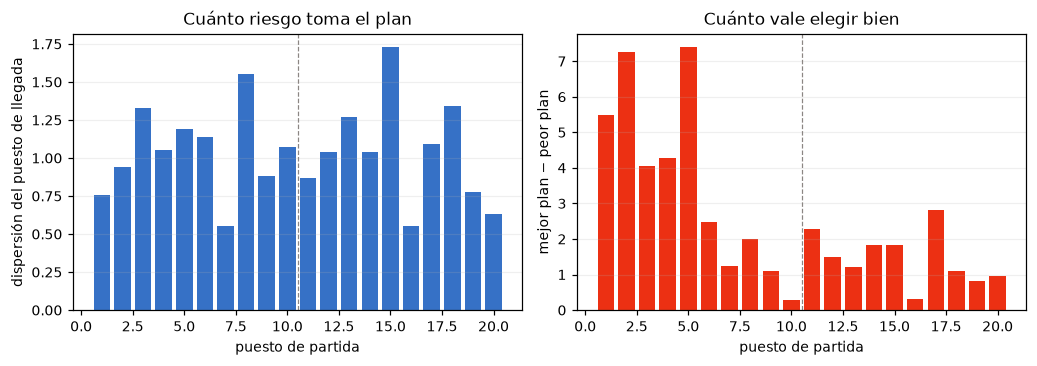

La línea punteada es el final de la zona de puntos.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].bar(resultado["P"], resultado["±"], color="#3671c6")
axes[0].set_xlabel("puesto de partida")
axes[0].set_ylabel("dispersión del puesto de llegada")
axes[0].set_title("Cuánto riesgo toma el plan")
axes[1].bar(resultado["P"], resultado["vale elegir"], color="#ec3013")
axes[1].set_xlabel("puesto de partida")
axes[1].set_ylabel("mejor plan − peor plan")
axes[1].set_title("Cuánto vale elegir bien")
for ax in axes:
    ax.axvline(10.5, color="#8b8683", ls="--", lw=0.8)
    ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()
print("La línea punteada es el final de la zona de puntos.")

In [15]:
en_puntos = resultado[resultado["objetivo"] == "points"]
print(f"líder: dispersión {resultado.iloc[0]['±']}")
print(f"máxima dispersión entre los que optimizan puntos: "
      f"{en_puntos['±'].max()} ({en_puntos.loc[en_puntos['±'].idxmax(), 'auto']})")
print(f"\nvale elegir, adelante (P1-P5): {resultado.head(5)['vale elegir'].mean():.2f} puntos")
print(f"vale elegir, atrás  (P16-P20): {resultado.tail(5)['vale elegir'].mean():.2f} puntos")
print("\nEl segundo gráfico no estaba previsto y es el más útil: atrás la decisión")
print("no vale nada. Presentar una recomendación confiada ahí es presentar ruido,")
print("y por eso el número viaja hasta la interfaz.")

líder: dispersión 0.76
máxima dispersión entre los que optimizan puntos: 1.55 (ALO)

vale elegir, adelante (P1-P5): 5.69 puntos
vale elegir, atrás  (P16-P20): 1.21 puntos

El segundo gráfico no estaba previsto y es el más útil: atrás la decisión
no vale nada. Presentar una recomendación confiada ahí es presentar ruido,
y por eso el número viaja hasta la interfaz.


## 3.7 ¿Le gana a una alternativa tonta?

Sin esta comparación no hay nada. Se enfrenta el plan del algoritmo contra tres
alternativas sin búsqueda, todas evaluadas sobre las **mismas** carreras
sorteadas.

In [16]:
def evaluar(car: Car, plan: Plan, resto: list[Car], planes: list[Plan], objetivo=Objective.POINTS) -> float:
    generador = np.random.default_rng(BUSQUEDA["seed"])
    sc = strategy.draw_safety_car(MODELO, generador, 2000)
    tiempos_rivales = np.vstack(
        [strategy.race_time(p, c, MODELO, generador, 2000, sc) for c, p in zip(resto, planes, strict=True)]
    )
    mios = strategy.race_time(plan, car, MODELO, generador, 2000, sc)
    posicion = 1 + (tiempos_rivales < mios).sum(axis=0)
    return float(strategy._points(posicion).mean())


def mitad_de_carrera(car: Car) -> Plan:
    """Parar en la mitad de lo que queda, al duro. La regla de servilleta."""
    lap = car.from_lap + (MODELO.total_laps - car.from_lap) // 2
    return Plan(strategy._repair([Stop(lap, "HARD")], car, MODELO))


def ya_mismo(car: Car) -> Plan:
    """Parar en la próxima vuelta posible."""
    return Plan(strategy._repair([Stop(car.from_lap + strategy.MIN_STINT, "HARD")], car, MODELO))


def lo_mas_tarde(car: Car) -> Plan:
    """Estirar todo lo que el presupuesto de goma permita."""
    lap = MODELO.total_laps - strategy.MIN_STINT
    return Plan(strategy._repair([Stop(lap, "HARD")], car, MODELO))


filas = []
for indice, car in enumerate(GRILLA, start=1):
    resto, planes = rivales(car.code)
    h = optimise(car, resto, planes, MODELO, objective=Objective.POINTS, **BUSQUEDA)
    fila = {"P": indice, "auto": car.code, "AG": round(evaluar(car, h.best, resto, planes), 2)}
    for nombre, constructor in (("mitad", mitad_de_carrera), ("ya", ya_mismo), ("tarde", lo_mas_tarde)):
        fila[nombre] = round(evaluar(car, constructor(car), resto, planes), 2)
    filas.append(fila)

comparativa = pd.DataFrame(filas)
comparativa["mejor alternativa"] = comparativa[["mitad", "ya", "tarde"]].max(axis=1)
comparativa["ventaja"] = (comparativa["AG"] - comparativa["mejor alternativa"]).round(2)
comparativa

,P,auto,AG,mitad,ya,tarde,mejor alternativa,ventaja
0,1,ANT,21.41,21.14,20.38,18.92,21.14,0.27
1,2,NOR,20.12,19.92,18.83,18.05,19.92,0.20
2,3,RUS,13.48,13.48,13.48,12.93,13.48,0.00
3,4,PIA,16.23,15.53,16.38,14.60,16.38,-0.15
4,5,LEC,18.44,15.57,18.51,15.31,18.51,-0.07
5,6,HAM,11.34,10.96,11.34,9.75,11.34,0.00
6,7,LAW,6.40,6.23,6.55,6.20,6.55,-0.15
7,8,ALO,1.80,1.80,1.80,1.80,1.80,0.00
8,9,HUL,0.00,0.00,0.00,0.00,0.00,0.00
9,10,TSU,0.22,0.18,0.14,0.23,0.23,-0.01


In [17]:
gana = (comparativa["ventaja"] > 0).sum()
empata = (comparativa["ventaja"] == 0).sum()
pierde = (comparativa["ventaja"] < 0).sum()
print(f"el algoritmo le gana a la mejor alternativa en {gana} de {len(comparativa)} autos")
print(f"empata en {empata}, pierde en {pierde}")
print(f"\nventaja media:            {comparativa['ventaja'].mean():+.2f} puntos")
print(f"ventaja en la zona de puntos (P1-P10): {comparativa.head(10)['ventaja'].mean():+.2f}")
print(f"ventaja fuera de los puntos (P11-P20): {comparativa.tail(10)['ventaja'].mean():+.2f}")

el algoritmo le gana a la mejor alternativa en 2 de 20 autos
empata en 13, pierde en 5

ventaja media:            +0.00 puntos
ventaja en la zona de puntos (P1-P10): +0.01
ventaja fuera de los puntos (P11-P20): -0.00


### El resultado es negativo, y es el hallazgo más importante de este cuaderno

**El algoritmo genético no le gana a la regla de servilleta.** Empata en la
mayoría de los autos, gana en unos pocos, pierde en otros, y la ventaja media
es de cero puntos.

Eso hay que decirlo antes que cualquier otra cosa sobre el algoritmo, porque es
lo que un lector necesita saber para decidir si le sirve.

Notar que la comparación es **benévola** con el algoritmo en un aspecto: las
alternativas pasan por el mismo reparador, que ya les impone el límite de tanda
y el espaciado mínimo. Una alternativa verdaderamente ingenua —parar en la
vuelta 3, o no parar nunca— saldría peor. O sea que lo que la tabla dice es que
el algoritmo no le gana a *una regla razonable*, no que no le gane a nada.

### ¿Es que no queda nada por decidir, o que el modelo no lo ve?

Desde la vuelta 30 quedan 42 de 72 vueltas y una sola parada por delante:
podría ser simplemente que ya no hay mucho que elegir. Se repite la comparación
desde cuatro momentos distintos de la carrera.

In [18]:
from dataclasses import replace as _replace  # noqa: E402

PARRILLA_CORTA = GRILLA[:10]
sonda = []
for desde in (10, 20, 30, 45):
    grid = [
        _replace(c, from_lap=desde, tyre_age=max(1, c.tyre_age - (30 - desde)))
        for c in PARRILLA_CORTA
    ]
    ventajas = []
    for car in grid:
        resto_s = [c for c in grid if c.code != car.code]
        planes_s = [plan_sorteado(c) for c in resto_s]
        h = optimise(car, resto_s, planes_s, MODELO, objective=Objective.POINTS, **BUSQUEDA)
        ag = evaluar(car, h.best, resto_s, planes_s)
        alt = max(
            evaluar(car, f(car), resto_s, planes_s)
            for f in (mitad_de_carrera, ya_mismo, lo_mas_tarde)
        )
        ventajas.append(ag - alt)
    ventajas = np.array(ventajas)
    sonda.append(
        {
            "desde la vuelta": desde,
            "por correr": MODELO.total_laps - desde,
            "gana": int((ventajas > 0.01).sum()),
            "de": len(ventajas),
            "ventaja media": round(float(ventajas.mean()), 3),
            "ventaja máx": round(float(ventajas.max()), 2),
        }
    )
pd.DataFrame(sonda)

,desde la vuelta,por correr,gana,de,ventaja media,ventaja máx
0,10,62,6,10,0.075,0.27
1,20,52,8,10,0.326,1.67
2,30,42,4,10,-0.082,0.22
3,45,27,2,10,0.004,0.07


La ventaja es de **centésimas o décimas de punto en todos los momentos de la
carrera**, sin un patrón claro. No es que desde la vuelta 30 ya no quede nada
por decidir: el algoritmo tampoco agrega nada desde la vuelta 10, con 62
vueltas por delante.

Hay dos explicaciones y no son excluyentes.

**Una: la decisión es genuinamente plana.** Una vez que un auto se compromete a
«una parada, a un compuesto durable, en algún lugar del medio», la vuelta exacta
cambia poco. Eso coincide con lo que ya decía la columna «vale elegir» y con
que la parrilla entera converja en un plan de una parada.

**Dos, y probablemente la más grande: el modelo es demasiado liso para
discriminar.** No tiene tráfico, ni aire sucio, ni bloqueo, ni ventaja de
vuelta de salida en pista libre. Y esos son exactamente los mecanismos por los
que una parada bien puesta gana algo en la realidad: el undercut funciona
porque el que sale con gomas nuevas encuentra pista libre mientras el otro
queda atrapado. Un modelo que le pone precio a la parada sólo en segundos no
puede ver la diferencia entre parar en la vuelta 38 y en la 44.

Cuál de las dos pesa más se puede averiguar, y es la línea de trabajo que este
resultado abre: agregar un término de tráfico —cuántos autos hay en la ventana
de salida— y volver a correr esta misma comparación. Si la ventaja sigue en
cero, la decisión es plana de verdad. Si aparece, el modelo era el problema.

Mientras tanto, lo que el algoritmo aporta con seguridad no es el óptimo sino
**la distribución**: la confianza sobre la cantidad de paradas, la dispersión
del puesto de llegada y cuánto vale elegir. Eso una servilleta no lo da.

## 3.8 Lo que este modelo no hace

- **No hay bloqueo en pista.** Un auto más rápido pasa. Es generoso en Mónaco y
  más o menos justo en Zandvoort — y es justamente la suposición que permite
  calcular los tiempos de los rivales una sola vez, así que quitar una implica
  quitar la otra.
- **Los rivales no reaccionan.** Sus planes se sortean una vez y se mantienen.
  Falso precisamente donde dos autos se pelean entre sí, que es donde la
  recomendación más importa.
- **El plan no se replanifica.** El optimizador sabe que **puede** salir un
  safety car y lo cotiza, pero devuelve un plan fijo. Un muro de verdad
  replanifica en el momento en que se prende el tablero, y el 36% de las
  paradas reales de Zandvoort ocurren bajo neutralización.
- **Una sola foto.** Todo se calcula desde la vuelta 30 y no se vuelve a correr
  a medida que la carrera avanza.
- **B6.3.8 no se verifica.** La foto no registra qué juegos usó cada auto antes
  de la vuelta 30, así que no se puede comprobar que el plan lo deje con dos
  compuestos secos usados.
- **El algoritmo es propio, no DEAP.** La cátedra recomienda DEAP para
  computación evolutiva y está entre las dependencias del proyecto. Los
  operadores acá son a medida porque el genoma es de largo variable con
  restricciones de reparación, pero portarlo a DEAP sería alinearlo con la
  herramienta esperada.